In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
BATCH_SIZE = 128

data_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=data_transform)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 20.8MB/s]


In [4]:
class Autoencoder(nn.Module):

  def __init__(self, latent_dim=32, hidden_dim=256):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU(),
    )

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid(),
    )


  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [5]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
epochs = 5

model.train()

for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()

    x_recon = model(x)

    loss = criterion(x_recon, x)

    loss.backward()

    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss / len(train_loader)

  print(f"epoch [{epoch + 1}/{epochs}], loss : {avg_loss:.6f}")

epoch [1/5], loss : 0.043495
epoch [2/5], loss : 0.018229
epoch [3/5], loss : 0.014427
epoch [4/5], loss : 0.012721
epoch [5/5], loss : 0.011771


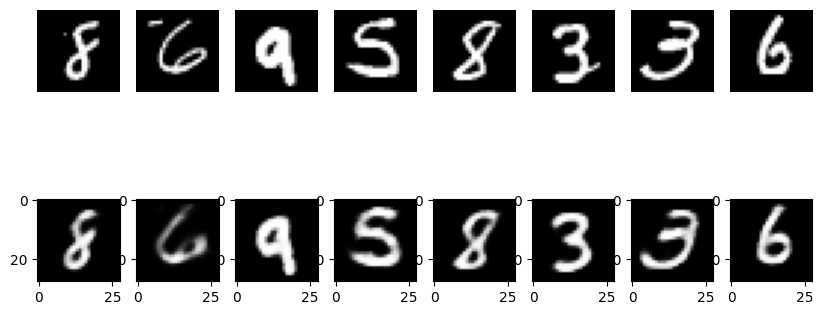

In [7]:
model.eval()

with torch.no_grad():
  x , _ = next(iter(train_loader))
  x = x.view(-1,784).to(device)

  x_recon = model(x)

  x = x.cpu()

  n =8
  plt.figure(figsize=(10,4.5))

  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    plt.subplot(2, n , i+1+n)
    plt.imshow(x_recon[i].view(28,28),cmap='gray')

  plt.show()


In [8]:
model.eval()

latents = []
labels = []

with torch.no_grad():
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)

    # Keep as tensors for torch.cat
    latents.append(z.cpu())
    labels.append(y)

  # Concatenate tensors
  latents = torch.cat(latents)
  labels = torch.cat(labels)

# Convert to numpy at the very end if needed
latents_np = latents.numpy()
labels_np = labels.numpy()

Latent dim is 32. Applying PCA projection to 2D...


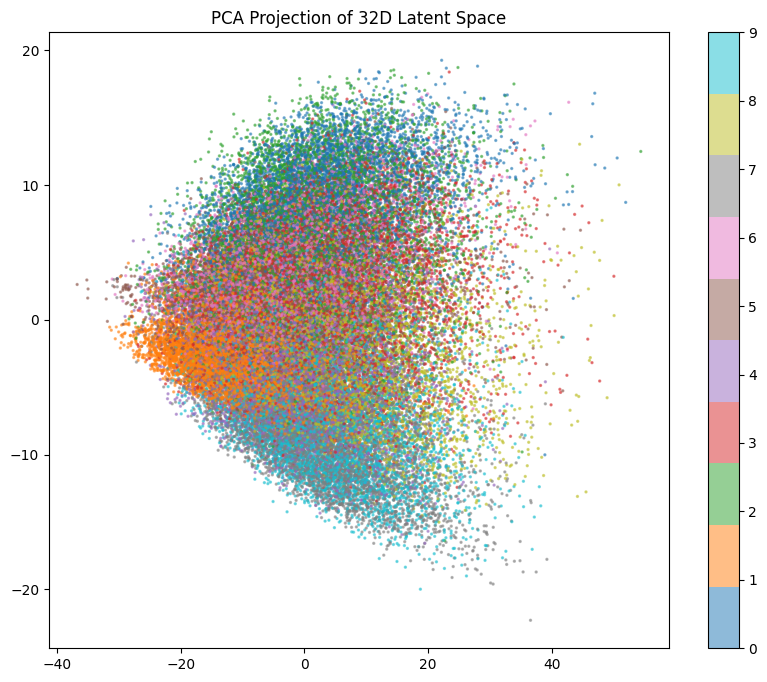

In [9]:
import numpy as np
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

def plot_latent_space(data, labels):
    dims = data.shape[1]

    plt.figure(figsize=(10, 8))

    if dims == 1:
        # 1D Histogram
        plt.hist(data, bins=50, alpha=0.7)
        plt.title("1D Latent Space Histogram")

    elif dims == 2:
        # 2D Scatter Plot
        plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=2, alpha=0.5)
        plt.colorbar()
        plt.title("2D Latent Space Scatter Plot")

    elif dims == 3:
        # 3D Rotatable Scatter Plot
        ax = plt.subplot(111, projection='3d')
        p = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels, cmap='tab10', s=2, alpha=0.5)
        plt.colorbar(p)
        plt.title("3D Latent Space Scatter Plot")

    else:
        # More than 3D: PCA Projection to 2D
        print(f"Latent dim is {dims}. Applying PCA projection to 2D...")
        pca = PCA(n_components=2)
        data_2d = pca.fit_transform(data)
        plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='tab10', s=2, alpha=0.5)
        plt.colorbar()
        plt.title(f"PCA Projection of {dims}D Latent Space")

    plt.show()

# Execute the plotting function
plot_latent_space(latents_np, labels_np)